This notebook performs data quality profiling, visualization, and missing data imputation on the Brazilian E-commerce Orders dataset using Python and Google Colab.


## Part A – Data Quality Profiling


In [2]:
import pandas as pd
df = pd.read_csv("data.csv")

In [3]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
df.shape

(23620, 8)

In [5]:
df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [6]:
df.isna().sum()

,0
order_id,0
customer_id,0
order_status,1
order_purchase_timestamp,1
order_approved_at,43
order_delivered_carrier_date,405
order_delivered_customer_date,692
order_estimated_delivery_date,1


In [7]:
df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,23620,23620,23619,23619,23577,23215,22928,23619
unique,23620,23620,7,23586,22974,21746,22863,430
top,23fb5e6768dd0cf8df7aaa74d80f8ec6,b54c3706d7d7a59b0f0754,delivered,2017-05-19 21:20:54,2018-02-27 04:31:10,2018-05-10 18:29:00,2017-12-02 00:26:45,2018-05-29 00:00:00
freq,1,1,22928,2,5,11,3,150


In [8]:
df["order_status"].value_counts()

,count
order_status,
delivered,22928
shipped,268
canceled,148
unavailable,140
invoiced,66
processing,66
created,3


In [9]:
def completeness(df):
  return 1 - df.isna().mean()


In [10]:
  completeness(df)

,0
order_id,1.000000
customer_id,1.000000
order_status,0.999958
order_purchase_timestamp,0.999958
order_approved_at,0.998180
order_delivered_carrier_date,0.982854
order_delivered_customer_date,0.970703
order_estimated_delivery_date,0.999958


In [11]:
def uniqueness(df, col):
  return df[col].nunique()/len(df)

In [12]:
uniqueness(df,"order_id")

1.0

## Part B – Visualization


In [13]:
df["order_purchase_timestamp"]=pd.to_datetime(df["order_purchase_timestamp"])

<Axes: >

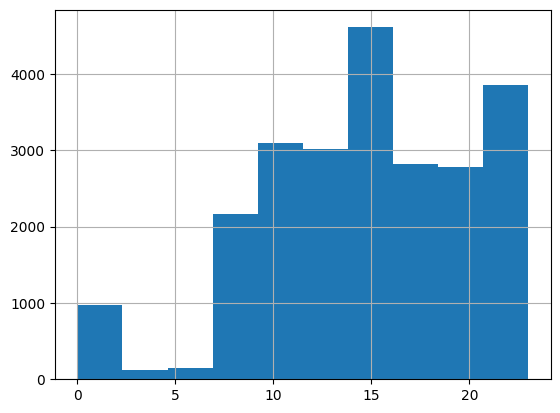

In [14]:
df["order_purchase_timestamp"].dt.hour.hist()

In [15]:
df["purchase_hour"] = df["order_purchase_timestamp"].dt.hour

<Axes: >

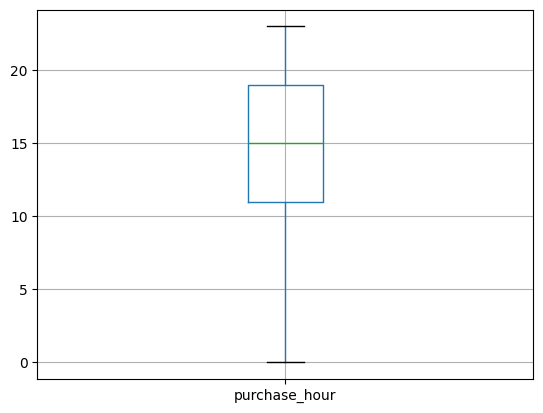

In [16]:
df.boxplot(column="purchase_hour")

## Part C – Missing Data Imputation


In [17]:
df1 = df.fillna(df.mean(numeric_only=True))

In [18]:
df2 = df.fillna("unknown")

In [19]:
df3 = df.dropna()

In [20]:
len(df), len(df1), len(df2), len(df3)

(23620, 23620, 23620, 22923)